<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Matter001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

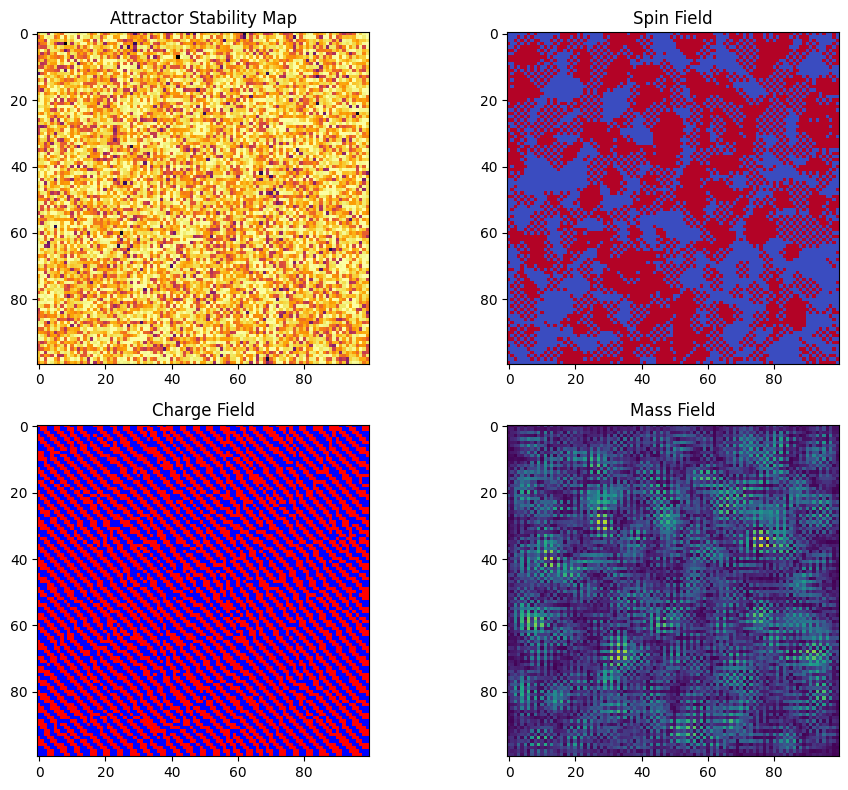

In [1]:
# 🧪 Matter001: Particle Genesis – HES Lattice Simulation

import numpy as np
import matplotlib.pyplot as plt

# --- Simulation Parameters ---
N = 100  # Lattice size (NxN)
steps = 500  # Evolution steps
entropy_seed_strength = 0.1  # Initial entropy gradient
curvature_threshold = 0.05  # Minimum curvature to qualify as attractor

# --- Initialize Entropic Lattice ---
S = np.random.rand(N, N) * entropy_seed_strength  # Entropy field
curvature_memory = np.zeros_like(S)
attractor_map = np.zeros_like(S)

# --- Evolution Function ---
def evolve(S):
    grad_x, grad_y = np.gradient(S)
    laplacian = np.gradient(grad_x)[0] + np.gradient(grad_y)[1]
    S_new = S - 0.01 * laplacian  # Entropic smoothing
    return S_new

# --- Simulation Loop ---
for t in range(steps):
    S = evolve(S)
    curvature = np.abs(np.gradient(np.gradient(S)[0])[0] + np.gradient(np.gradient(S)[1])[1])
    curvature_memory += curvature
    attractor_map += (curvature > curvature_threshold).astype(float)

# --- Extract Quantized Properties ---
spin_field = np.sign(np.gradient(S)[0] * np.gradient(S)[1])
charge_field = np.sign(np.gradient(S)[0] - np.gradient(S)[1])
mass_field = curvature_memory / steps

# --- Visualization ---
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs[0, 0].imshow(attractor_map, cmap='inferno'); axs[0, 0].set_title("Attractor Stability Map")
axs[0, 1].imshow(spin_field, cmap='coolwarm'); axs[0, 1].set_title("Spin Field")
axs[1, 0].imshow(charge_field, cmap='bwr'); axs[1, 0].set_title("Charge Field")
axs[1, 1].imshow(mass_field, cmap='viridis'); axs[1, 1].set_title("Mass Field")
plt.tight_layout(); plt.show()
